<a href="https://colab.research.google.com/github/NietoEmmanuel/SIMULACION-I/blob/main/Examen3erParcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import random as r
import math

<center>


<h1><b>Examen</b></h1>
<h3><i>3er parcial</i></h3>
<br>
<b>Alumno:</b> Emmanuel Nieto Mejía<br>
<b>Boleta:</b> 22330312<br>
<b>Materia:</b> Simulacion I<br>
<b>Profesor:</b> Ricardo Medel Esquivel<br>
<br>
<b>Fecha:</b> 21 de Junio de 2026<br>

</center>




# 1. Sistema de línea de espera con dos servidores

**EN SERIE**

Consideremos un sistema de dos servidores en el que los clientes llegan de acuerdo
con un proceso Poisson no homogéneo, y supongamos que cada llegada debe ser
atendida primero por el servidor 1 y al terminar el servicio en 1, el cliente pasa al
servidor 2. Tal sistema es un sistema de cola en tándem o secuencial.
Al llegar, el cliente pasará con el servidor I si éste se encuentra desocupado, o se
formará en la fila de éste en caso contrario. De manera análoga, cuando el cliente
termine el servicio en el servidor 1, entra a servicio con el servidor 2 si éste se
encuentra libre, o se formará en su fila. Después de ser atendido en el servidor 2, el
cliente sale del sistema.

**EN PARALELO**

Consideremos un modelo en el que los clientes llegan a un sistema con dos servidores.
Al llegar, un cliente se forma en una fila si ambos servidores están ocupados, entra servicio con el servidor 1 si ese servidor está desocupado, o bien con el servidor 2 en
caso contrario. Cuando el cliente concluye el servicio con un servidor (sin importar
cuál sea), sale del sistema y el cliente que ha estado formado más tiempo (si hay
clientes en la cola) entra a servicio.

In [14]:

# Función
def Exp(tasa):
    return random.expovariate(tasa)

def LineaEsperaSerie(T, lamb, mu1, mu2):
    t = 0.0
    NA = 0
    ND = 0
    n1 = 0
    n2 = 0

    tA = Exp(lamb)
    t1 = float("inf")
    t2 = float("inf")

    # Estadísticas
    area1 = 0.0
    area2 = 0.0
    ocupado1 = 0.0
    ocupado2 = 0.0
    ultimo_evento = 0.0

    # Tiempo de llegada de cada cliente al sistema
    llegadas = []
    suma_W = 0.0

    # Simulación
    while True:
        t_evento = min(tA, t1, t2)

        # Acumular estadísticas sólo hasta T
        if t_evento <= T:
            dt = t_evento - ultimo_evento
            area1 += n1 * dt
            area2 += n2 * dt

            if n1 > 0:
                ocupado1 += dt
            if n2 > 0:
                ocupado2 += dt

            ultimo_evento = t_evento

        # CASO 1: ARRIBO
        if tA <= t1 and tA <= t2 and tA <= T:
            t = tA
            NA += 1
            n1 += 1
            llegadas.append(t)
            tA = t + Exp(lamb)

            if n1 == 1:
                t1 = t + Exp(mu1)

        # CASO 2: SALIDA SERVIDOR 1 (Antes de T)
        elif t1 < tA and t1 <= t2 and t1 <= T:
            t = t1
            n1 -= 1
            n2 += 1

            if n1 == 0:
                t1 = float("inf")
            else:
                t1 = t + Exp(mu1)

            if n2 == 1:
                t2 = t + Exp(mu2)

        # CASO 3: SALIDA SERVIDOR 2 (Antes de T)
        elif t2 < tA and t2 < t1 and t2 <= T:
            t = t2
            ND += 1
            n2 -= 1

            llegada_cliente = llegadas.pop(0)
            W = t - llegada_cliente
            suma_W += W

            if n2 == 0:
                t2 = float('inf')
            else:
                t2 = t + Exp(mu2)

        # DESPUÉS DE T (Vaciado del sistema)
        elif min(tA, t1, t2) > T:
            tA = float("inf")

            if n1 == 0 and n2 == 0:
                break

            t_siguiente = min(t1, t2)

            if t_siguiente == t1:
                t = t1
                n1 -= 1
                n2 += 1

                if n1 == 0:
                    t1 = float("inf")
                else:
                    t1 = t + Exp(mu1)

                if n2 == 1:
                    t2 = t + Exp(mu2)

            elif t_siguiente == t2:
                t = t2
                ND += 1
                n2 -= 1

                llegada_cliente = llegadas.pop(0)
                W = t - llegada_cliente
                suma_W += W

                if n2 == 0:
                    t2 = float("inf")
                else:
                    t2 = t + Exp(mu2)

    # Resultados
    rho1 = ocupado1 / T
    rho2 = ocupado2 / T
    L1 = area1 / T
    L2 = area2 / T
    L = L1 + L2
    W = suma_W / ND if ND > 0 else 0

    print("========== SIMULACIÓN EN SERIE ==========")
    print(f"ρ1 = {rho1:.4f}")
    print(f"ρ2 = {rho2:.4f}")
    print(f"L1 = {L1:.4f}")
    print(f"L2 = {L2:.4f}")
    print(f"L total = {L:.4f}")
    print(f"W = {W:.4f}")
    print("Clientes que llegaron:", NA)
    print("Clientes que salieron:", ND)


def LineaEsperaParalelo(T, lamb, mu1, mu2):
    t = 0.0
    NA = 0
    ND = 0

    estado = [0, 0, 0]

    tA = Exp(lamb)
    t1 = float("inf")
    t2 = float("inf")

    # Estadísticas
    area_clientes = 0.0
    ocupado1 = 0.0
    ocupado2 = 0.0
    ultimo_evento = 0.0

    tiempos_llegada = {}
    suma_W = 0.0

    # Simulación
    while True:
        t_evento = min(tA, t1, t2)
        n = estado[0]

        # Acumular estadísticas sólo hasta T
        if t_evento <= T:
            dt = t_evento - ultimo_evento
            area_clientes += n * dt

            if estado[1] > 0:
                ocupado1 += dt
            if estado[2] > 0:
                ocupado2 += dt

            ultimo_evento = t_evento

        # CASO 1: ARRIBO
        if tA <= t1 and tA <= t2 and tA <= T:
            t = tA
            NA += 1
            tiempos_llegada[NA] = t
            tA = t + Exp(lamb)

            if n == 0:
                estado = [1, NA, 0]
                t1 = t + Exp(mu1)
            elif n == 1 and estado[1] != 0:
                estado = [2, estado[1], NA]
                t2 = t + Exp(mu2)
            elif n == 1 and estado[2] != 0:
                estado = [2, NA, estado[2]]
                t1 = t + Exp(mu1)
            else:
                estado[0] = n + 1
                estado.append(NA)

        # CASO 2: SALIDA SERVIDOR 1 (Antes de T)
        elif t1 < tA and t1 <= t2 and t1 <= T:
            t = t1
            ND += 1
            cliente_libre = estado[1]

            W = t - tiempos_llegada[cliente_libre]
            suma_W += W

            if n == 1:
                estado = [0, 0, 0]
                t1 = float("inf")
            elif n == 2:
                estado = [1, 0, estado[2]]
                t1 = float("inf")
            else:
                siguiente_cliente = estado.pop(3)
                estado[0] = n - 1
                estado[1] = siguiente_cliente
                t1 = t + Exp(mu1)

        # CASO 3: SALIDA SERVIDOR 2 (Antes de T)
        elif t2 < tA and t2 < t1 and t2 <= T:
            t = t2
            ND += 1
            cliente_libre = estado[2]

            W = t - tiempos_llegada[cliente_libre]
            suma_W += W

            if n == 1:
                estado = [0, 0, 0]
                t2 = float("inf")
            elif n == 2:
                estado = [1, estado[1], 0]
                t2 = float("inf")
            else:
                siguiente_cliente = estado.pop(3)
                estado[0] = n - 1
                estado[2] = siguiente_cliente
                t2 = t + Exp(mu2)

        # DESPUÉS DE T (Vaciado del sistema)
        elif min(tA, t1, t2) > T:
            tA = float("inf")

            if estado[0] == 0:
                break

            t_siguiente = min(t1, t2)

            if t_siguiente == t1:
                t = t1
                ND += 1
                cliente_libre = estado[1]

                W = t - tiempos_llegada[cliente_libre]
                suma_W += W

                if estado[0] == 1:
                    estado = [0, 0, 0]
                    t1 = float("inf")
                elif estado[0] == 2:
                    estado = [1, 0, estado[2]]
                    t1 = float("inf")
                else:
                    siguiente_cliente = estado.pop(3)
                    estado[0] -= 1
                    estado[1] = siguiente_cliente
                    t1 = t + Exp(mu1)

            elif t_siguiente == t2:
                t = t2
                ND += 1
                cliente_libre = estado[2]

                W = t - tiempos_llegada[cliente_libre]
                suma_W += W

                if estado[0] == 1:
                    estado = [0, 0, 0]
                    t2 = float("inf")
                elif estado[0] == 2:
                    estado = [1, estado[1], 0]
                    t2 = float("inf")
                else:
                    siguiente_cliente = estado.pop(3)
                    estado[0] -= 1
                    estado[2] = siguiente_cliente
                    t2 = t + Exp(mu2)

    # Resultados
    rho1 = ocupado1 / T
    rho2 = ocupado2 / T
    L = area_clientes / T
    W = suma_W / ND if ND > 0 else 0

    print("\n========== SIMULACIÓN EN PARALELO ==========")
    print(f"ρ1 = {rho1:.4f}")
    print(f"ρ2 = {rho2:.4f}")
    print(f"L total = {L:.4f}")
    print(f"W = {W:.4f}")
    print("Clientes que llegaron:", NA)
    print("Clientes que salieron:", ND)


# =====================
# PARAMETROS
# =====================
PARAMETROS = {"T": 10000, "lamb": 2, "mu1": 3, "mu2": 4 }

LineaEsperaSerie(**PARAMETROS)
LineaEsperaParalelo(**PARAMETROS)


========== SIMULACIÓN EN SERIE ==========
ρ1 = 0.6706
ρ2 = 0.5019
L1 = 2.0311
L2 = 0.9900
L total = 3.0211
W = 1.5011
Clientes que llegaron: 20127
Clientes que salieron: 20127

========== SIMULACIÓN EN PARALELO ==========
ρ1 = 0.4226
ρ2 = 0.1768
L total = 0.6500
W = 0.3283
Clientes que llegaron: 19797
Clientes que salieron: 19797


# 2. Variables antiteticas

 El método de variables antitéticas es una técnica de reducción de varianza utilizada en los métodos de Monte Carlo . Dado que el error en la señal simulada (mediante métodos de Monte Carlo ) tiene una convergencia de raíz cuadrada de uno sobre uno , se requiere un número muy grande de trayectorias de muestra para obtener un resultado preciso. El método de variables antitéticas reduce la varianza de los resultados de la simulación.

 Podemos reducir la varianza si $\text{cov}(X_1, X_2)$ es negativa.
Variables antitéticas a las que tienen $\text{Cov}$ negativa.

Ejemplo:

1.   $U$ y $1-U$, con $U \sim U(0,1)$ son antitéticos.



**Estimar la siguiente integral:**

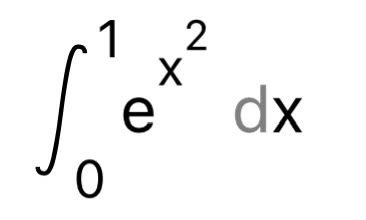

In [12]:

def f(x):
    return np.exp(x**2)

# 2. Método Monte Carlo Crudo
def mc1(f, N):
    s = 0
    for i in range(N):
        U = r.random()
        s += f(U)
    return s / N

# 3. Método Monte Carlo con Variables Antitéticas
def mc(f, N):
    s = 0
    for i in range(N):
        U = r.random()
        s += (f(U) + f(1 - U)) / 2
    return s / N

l_estandar = []
l_antiteticas = []

for i in range(100):
    l_estandar.append(mc1(f, 1000))
    l_antiteticas.append(mc(f, 1000))

print("--- RESULTADOS CON N = 1000 ---")
print(f"Aprox con Monte Carlo Crudo: {np.mean(l_estandar):.6f}")
print(f"Varianza Estándar: {np.var(l_estandar):.6e}")
print(f"Aprox con Monte Carlo Antitéticas: {np.mean(l_antiteticas):.6f}")
print(f"Varianza Antitéticas: {np.var(l_antiteticas):.6e}")

# Porcentaje de reducción de varianza
reduccion = (np.var(l_estandar) - np.var(l_antiteticas)) / np.var(l_estandar)
print(f"Reducción de varianza: {reduccion * 100:.2f}%")



--- RESULTADOS CON N = 1000 ---
Aprox con Monte Carlo Crudo: 1.461657
Varianza Estándar: 2.210457e-04
Aprox con Monte Carlo Antitéticas: 1.462655
Varianza Antitéticas: 2.519918e-05
Reducción de varianza: 88.60%


# 3. Bootstrap yJackknife

**BOOTSRAP**

Esta es una muestra aleatoria de 12 tiempos de entrega:

\[ 35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40 \]

Instrucciones:
1.   Use la muestra original de  observaciones y genere  muestras Bootstrap.
2.   Para cada muestra $B$ calcule la media
3. Al final:
   *   Obtenga la media de las 1000
   *   Calcule la desviación estándar.
   *   Determine los percentiles $2.5\%$ y $97.5\%$ para construir el intervalo de confianza $B$ del $95\%$

In [12]:
import random as r
import statistics as st

def bootstrap_sim():
    # Tiempos de entrega
    muestra = [35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]

    # Remuestreos Bootstrap
    B_rep = 1000
    # Tiempos de entrega
    n_datos = len(muestra)

    medias_bootstrap = []

    for _ in range(B_rep):

        muestra_b = r.choices(muestra, k=n_datos)

        media_b = sum(muestra_b) / n_datos

        medias_bootstrap.append(media_b)

    # Calculo la media y desviación estándar de bootstrap
    media_bootstrap = st.mean(medias_bootstrap)
    desv_bootstrap = st.stdev(medias_bootstrap)

    medias_ordenadas = sorted(medias_bootstrap)

    # Calculo d elos percentiles
    p025 = medias_ordenadas[int(0.025 * B_rep)]
    p975 = medias_ordenadas[int(0.975 * B_rep)]

    # Imprimir resultados
    print("Media bootstrap:", media_bootstrap)
    print("Desviación estándar Bootstrap :", desv_bootstrap)
    print("Percentil 2.5%:", p025)
    print("Percentil 97.5%:", p975)
    print("IC 95%:", (p025, p975))

bootstrap_sim()


Media bootstrap: 40.007
Desviación estándar Bootstrap : 0.8927474435684474
Percentil 2.5%: 38.333333333333336
Percentil 97.5%: 41.833333333333336
IC 95%: (38.333333333333336, 41.833333333333336)


# *3. Jackknife*

Tenemos una muestra de $n$ datos. En esta técnica eliminamos uno de los datos para obtener $n$ muestras de tamaño $n-1$.

Para cada muestra calculamos el estadístico $\hat{\theta}_i$ y luego obtenemos el promedio del Jackknife:
$$ \bar{\theta} = \frac{1}{n} \sum_{i=1}^{n} \hat{\theta}_i $$

y la varianza:
$$ \text{Var}_{\text{Jac}} = \frac{n-1}{n} \sum_{i=1}^{n} \left( \bar{\theta} - \hat{\theta}_i \right)^2 $$

---

**Ejercicio:** Programar usando la muestra del ejercicio del Bootstrap

In [22]:

def jackknife():
    muestra = [35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]
    n = len(muestra)

    medias_jackknife = []

    for i in range(n):
        # Eliminar la observación i
        muestra_j = muestra[:i] + muestra[i+1:]

        # Media de la submuestra
        media_j = sum(muestra_j) / (n - 1)
        medias_jackknife.append(media_j)

    # Promedio del Jackknife
    theta = st.mean(medias_jackknife)

    # Varianza del Jackknife
    Var_Jac = ((n - 1) / n) * sum((theta - theta_i) ** 2 for theta_i in medias_jackknife)

    # Error estándar
    error_estandar = math.sqrt(Var_Jac)

    print("===== JACKKNIFE =====")
    print("Promedio Jackknife (theta):", theta)
    print("Varianza Jackknife (Var_Jac):", Var_Jac)
    print("Error estándar:", error_estandar)

jackknife()


===== JACKKNIFE =====
Promedio Jackknife (theta): 40.0
Varianza Jackknife (Var_Jac): 0.8333333333333356
Error estándar: 0.9128709291752781
